<a href="https://colab.research.google.com/github/Aryamaan777/Finance/blob/BasicML/BasicML/Comparing_ML_Models_vs_Naive_Benchmarks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import xgboost as xgb
import matplotlib.pyplot as plt
from xgboost import XGBClassifier, XGBRegressor

In [ ]:
# --- 1. REAL DATA INGESTION ---
ticker = "SPY"
print(f"Downloading Real Data for {ticker}...")
df = yf.download(ticker, start="2010-01-01", end="2024-06-01", progress=False)

# Flatten MultiIndex if necessary (yfinance update fix)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)

# Calculate Daily Returns
df['Return'] = df['Close'].pct_change()
df['Log_Ret'] = np.log(df['Close'] / df['Close'].shift(1))
df.dropna(inplace=True)
df.head()

/tmp/ipython-input-1006199868.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start="2010-01-01", end="2024-06-01", progress=False)


Price,Close,High,Low,Open,Volume,Return,Log_Ret
Date,,,,,,,
2010-01-05,85.253029,85.290545,84.667820,84.975433,111579900,0.002647,0.002644
2010-01-06,85.313072,85.523147,85.102998,85.170519,116074400,0.000704,0.000704
2010-01-07,85.673195,85.778232,84.915422,85.155508,131091100,0.004221,0.004212
2010-01-08,85.958275,85.995791,85.275533,85.448092,126402800,0.003328,0.003322
2010-01-11,86.078346,86.378449,85.710710,86.340939,106375700,0.001397,0.001396


In [ ]:
# --- 2. FEATURE ENGINEERING (The Inputs) ---
# We need features that capture "State" (Trend, Volatility)

# A. Volatility Features (for both models)
df['Vol_10'] = df['Log_Ret'].rolling(10).std() * np.sqrt(252)
df['Vol_50'] = df['Log_Ret'].rolling(50).std() * np.sqrt(252)

# B. Momentum Features
df['Ret_5'] = df['Close'].pct_change(5)
df['Ret_20'] = df['Close'].pct_change(20)

# C. Distance from Trend (Mean Reversion)
df['Dist_SMA200'] = (df['Close'] / df['Close'].rolling(200).mean()) - 1

# D. The Targets (What we want to predict)
# Target 1: Direction (1 if Tomorrow > 0, else 0)
df['Target_Dir'] = np.where(df['Return'].shift(-1) > 0, 1, 0)

# Target 2: Volatility (Next 5 days realized volatility)
df['Target_Vol'] = df['Log_Ret'].rolling(5).std().shift(-5) * np.sqrt(252) * 100

df.dropna(inplace=True)
df.head()

Price,Close,High,Low,Open,Volume,Return,Log_Ret,Vol_10,Vol_50,Ret_5,Ret_20,Dist_SMA200,Target_Dir,Target_Vol
Date,,,,,,,,,,,,,,
2010-10-19,88.830948,89.683259,88.290636,89.181005,280604700,-0.013104,-0.013191,0.094249,0.161987,-0.002393,0.024127,0.048288,1,5.852623
2010-10-20,89.698486,90.132253,88.937491,88.990761,200051800,0.009766,0.009719,0.104559,0.162583,-0.000424,0.039235,0.058248,1,3.685728
2010-10-21,89.896339,90.626894,89.196225,90.101811,221585500,0.002206,0.002203,0.103415,0.148549,0.005704,0.050044,0.060295,1,3.498010
2010-10-22,90.063751,90.200731,89.797404,90.033311,108212400,0.001862,0.001861,0.101374,0.147468,0.005522,0.030744,0.061995,1,3.301447
2010-10-25,90.330116,91.136775,90.261629,90.664956,151145700,0.002958,0.002953,0.101544,0.147081,0.003551,0.038768,0.064861,1,2.322535


In [ ]:
# --- 3. TRAIN / TEST SPLIT (Respecting Time) ---
# Train on 2010-2019 (The Bull Market)
# Test on 2020-2024 (Covid, Inflation, AI Boom)
split_date = "2020-01-01"
train = df[df.index < split_date]
test = df[df.index >= split_date].copy()

features = ['Vol_10', 'Vol_50', 'Ret_5', 'Ret_20', 'Dist_SMA200']

In [ ]:
# --- 4. TRAIN THE AI MODELS ---

print("Training Alpha Engine (Direction)...")
model_dir = XGBClassifier(
    n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42, eval_metric='logloss'
)
model_dir.fit(train[features], train['Target_Dir'])

print("Training Risk Engine (Volatility)...")
model_vol = XGBRegressor(
    n_estimators=100, max_depth=3, learning_rate=0.05, random_state=42
)
model_vol.fit(train[features], train['Target_Vol'])

Training Alpha Engine (Direction)...
Training Risk Engine (Volatility)...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [ ]:
# --- 5. GENERATE PREDICTIONS ON TEST SET ---
# We predict "Tomorrow" using "Today's" data
test['Pred_Signal'] = model_dir.predict(test[features])
test['Pred_Vol'] = model_vol.predict(test[features])

In [ ]:
# --- 6. STRATEGY CONSTRUCTION ---

# A. Benchmark 1: Buy & Hold
test['Strat_BuyHold'] = test['Return']

# B. Benchmark 2: Simple Moving Average (Golden Cross)
# Note: We calculate SMA on the fly for the test set
test['SMA_50'] = test['Close'].rolling(50).mean()
test['SMA_200'] = test['Close'].rolling(200).mean()
# Signal: 1 if 50 > 200 (Golden Cross)
test['Signal_SMA'] = np.where(test['SMA_50'] > test['SMA_200'], 1, 0)
test['Strat_SMA'] = test['Signal_SMA'].shift(1) * test['Return']

# C. AI Strategy: "The Sniper"
# Logic: Trade the Directional Model ONLY if Predicted Volatility is < Threshold
# We set threshold dynamically (Median of training data volatility to avoid look-ahead bias)
vol_threshold = train['Target_Vol'].median()*10
print(f"Sniper Volatility Threshold: {vol_threshold:.2f}%")

test['Filter_Mask'] = np.where(test['Pred_Vol'] < vol_threshold, 1, 0)
test['Signal_Sniper'] = test['Pred_Signal'] * test['Filter_Mask']
test['Strat_Sniper'] = test['Signal_Sniper'].shift(1) * test['Return']

Sniper Volatility Threshold: 97.05%



--- RESULTS (2020-2024) ---
Strat_BuyHold: Ret: 74.6% | Sharpe: 0.69
Strat_SMA: Ret: 68.8% | Sharpe: 1.15
Strat_Sniper: Ret: 111.9% | Sharpe: 0.93


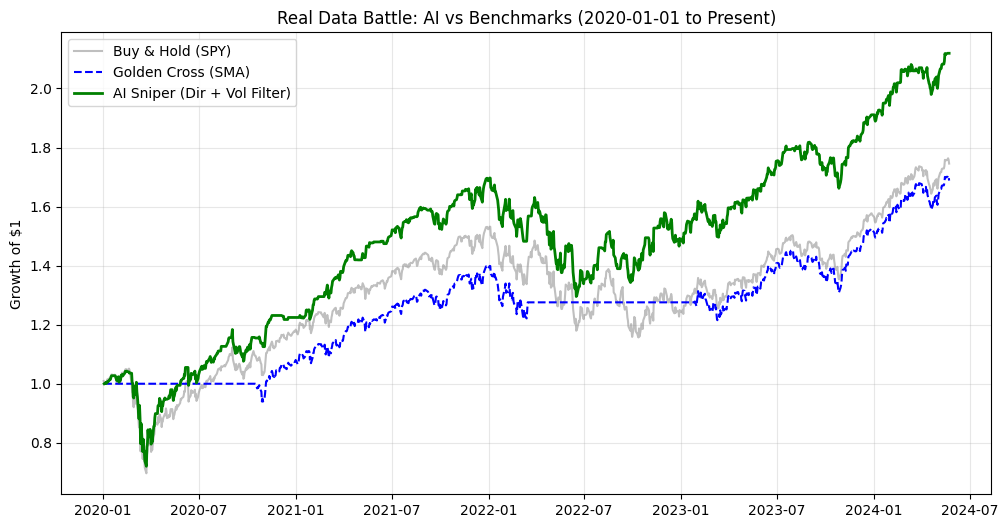

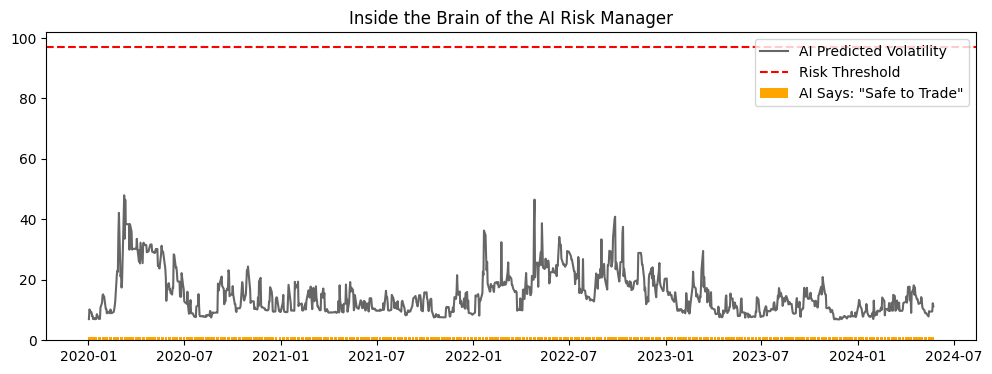

In [ ]:
# --- 7. EVALUATION & PLOTTING ---
strategies = ['Strat_BuyHold', 'Strat_SMA', 'Strat_Sniper']
cum_rets = (1 + test[strategies]).cumprod()

# Calc Metrics
def get_metrics(s):
    total = (s + 1).cumprod().iloc[-1] - 1
    sharpe = s.mean() / s.std() * np.sqrt(252) if s.std() > 0 else 0
    return f"Ret: {total*100:.1f}% | Sharpe: {sharpe:.2f}"

print("\n--- RESULTS (2020-2024) ---")
for strat in strategies:
    print(f"{strat}: {get_metrics(test[strat])}")

# Plot
plt.figure(figsize=(12, 6))
plt.plot(cum_rets['Strat_BuyHold'], label='Buy & Hold (SPY)', color='gray', alpha=0.5)
plt.plot(cum_rets['Strat_SMA'], label='Golden Cross (SMA)', color='blue', linestyle='--')
plt.plot(cum_rets['Strat_Sniper'], label='AI Sniper (Dir + Vol Filter)', color='green', linewidth=2)

plt.title(f"Real Data Battle: AI vs Benchmarks ({split_date} to Present)")
plt.ylabel("Growth of $1")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Show the Filter in Action
plt.figure(figsize=(12, 4))
plt.bar(test.index, test['Filter_Mask'], color='orange', width=2, label='AI Says: "Safe to Trade"')
plt.plot(test['Pred_Vol'], color='black', alpha=0.6, label='AI Predicted Volatility')
plt.axhline(vol_threshold, color='red', linestyle='--', label='Risk Threshold')
plt.title("Inside the Brain of the AI Risk Manager")
plt.legend(loc='upper right')
plt.show()